In [10]:
import jax.numpy as jnp
import numpy as np
from matplotlib import pyplot as plt
import scanpy as sc
import pandas as pd
import seaborn as sns
from gstatot import StatOT, gStatOT, Metric_Evaluator, utils

sns.set_context("paper", font_scale=1.5)
sns.set_theme(style="ticks")

In [11]:
# The synthetic data, GRN_simulation_dropout=0.5_seed=0.h5ad, can be downloaded at https://doi.org/10.5281/zenodo.20723235
# or generated by running the make_GRN_sims.py script in extra/data_preprocessing/sim/GRN_simulation/ after 
# downloading the BoolODE repo at https://github.com/murali-group/BoolODE, which is also archived at https://doi.org/10.5281/zenodo.20723235.

data_dir = '../extra/data/sim_data/'
sim_adata = sc.read_h5ad(f"{data_dir}/GRN_simulation_dropout=0.5_seed=0.h5ad") # load sim adata with ground truth trajectories and fate probability estimates
sim_adata

# label genes to match manuscript
gene_names = {'G': 'G_g', 'D': 'G_d', 'tf1': 'G_1', 'tf2' : 'G_2', 'tf3': 'G_3', 'tf4': 'G_4', 'tfB1': 'G_B1', 'tfB2': 'G_B2', 'tfB11': 'G_B11', 'tfB22': 'G_B22'}
sim_adata.var_names = [gene_names.get(g, g) for g in sim_adata.var_names]

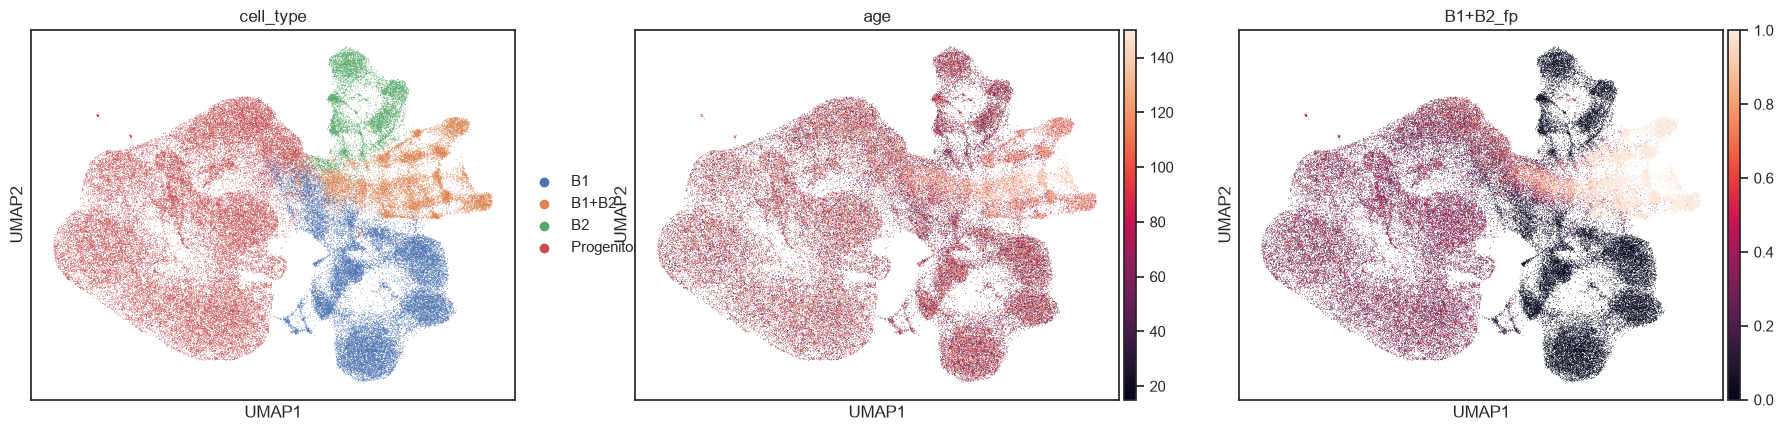

In [12]:
# Cell type and age annotations along with the empirical fate probabilities estimated using simulated trajectories. 
sc.pl.umap(sim_adata, color=['cell_type', 'age', 'B1+B2_fp'])

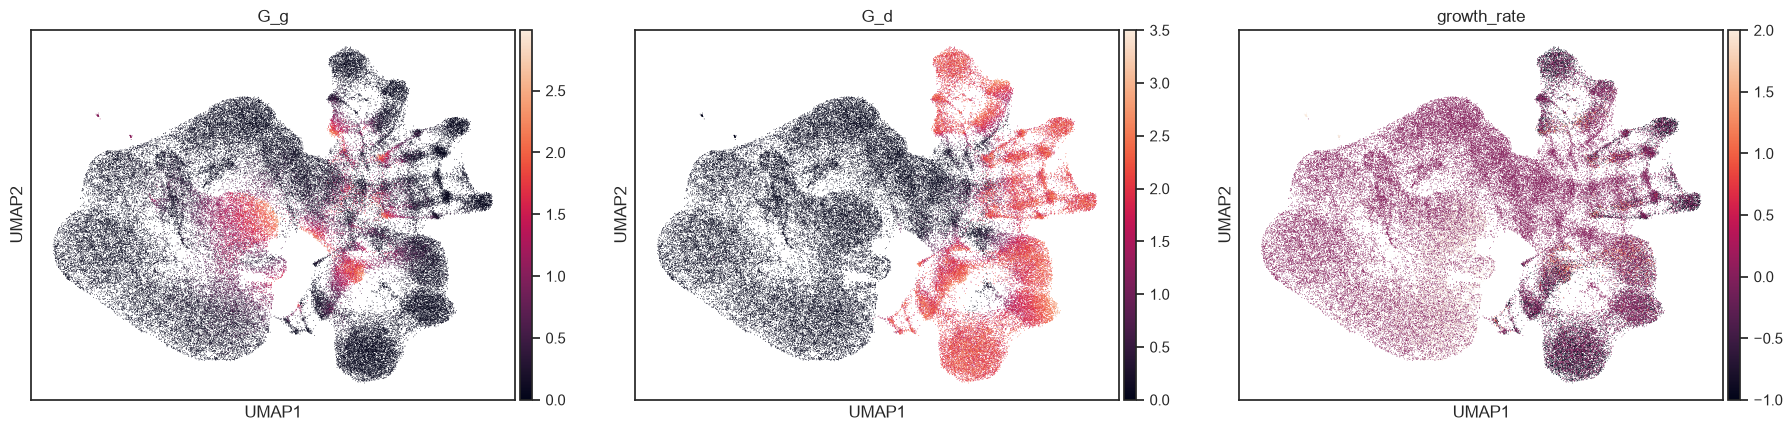

In [13]:
# growth and death genes, 'G_g' and 'G_d' along with the cell growth rates R
sc.pl.umap(sim_adata, color=['G_g', 'G_d', 'growth_rate'])

In [14]:
seed = 42 
n = 25
dt = 0.01 # simulation time step

adata_keys = {'time_key': 'age', 
              'growth_rate_key': 'growth_rate', 
              'embed_key': 'X_pca',
              'cell_type_key': 'cell_type'}

downsampled_adata = utils.downsample_adata_by_age(sim_adata, n=n, 
                                                  time_key=adata_keys['time_key'], 
                                                  PRNG_KEY=seed)

## gStatOT

Ran 4900 iterations in 0.16 minutes.
duality gap: 9.563e-04
max constraint error: 2.811e-06



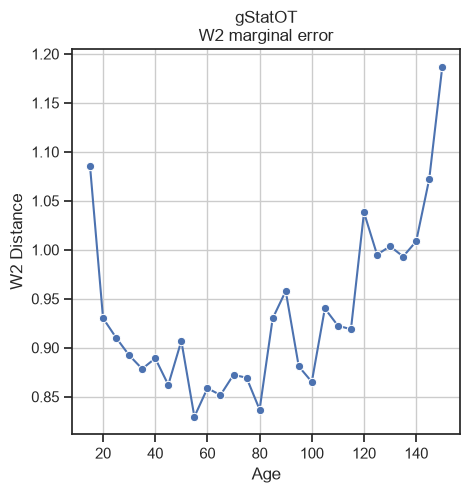

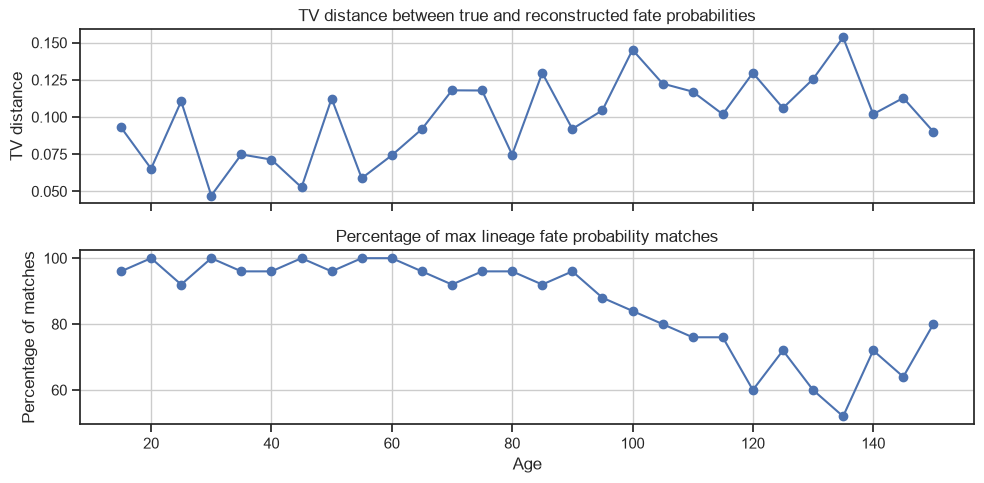

In [15]:
gSOT = gStatOT(adata=downsampled_adata.copy(), adata_keys=adata_keys, dt=dt, dtype=jnp.float32)

gSOT_params = {'lam': 17.5, # smoothing parameter
               'epsilon2': 0.015} # noise level estimate

gSOT.fit(model_params=gSOT_params, 
         verbose=True,
        )

gSOT.get_lin_fate_probs(label_key=adata_keys['cell_type_key'], 
                        all_labels=np.unique(sim_adata.obs[adata_keys['cell_type_key']]))

method_str = 'gStatOT' 

# compare gStatOT fate probability predictions to the simulated ground truth stored in sim_adata

gsot_metric_tests = Metric_Evaluator(method=method_str,
                                        test_adata=gSOT.adata,
                                        true_adata=sim_adata,
                                        time_key=adata_keys['time_key'],
                                        embed_key=adata_keys['embed_key'],
                                        exp_dir=None,
                                        full_supp=True)

gsot_metric_tests.w2_marginal_error()
gsot_metric_tests.fp_tv_error(label_key=adata_keys['cell_type_key'])

In [16]:
def death_props(adata, full_supp=True):
    """Compute the proportion of cells that are dead at each time point."""
    time_key = 'age'
    cell_type_key = 'cell_type'
    growth_rate_key = 'growth_rate'
    dead_prop = {ct : [] for ct in np.unique(adata.obs[cell_type_key])}
    for t in np.unique(adata.obs[time_key]):
        t_mask = adata.obs[time_key] == t
        if full_supp:
            pi = adata.obsp[f'pi_{t}']
            marginal = jnp.sum(pi, axis=0)
            sink_mask = adata.obs[growth_rate_key] < 0
            sink_growth = adata.obs[growth_rate_key]
        else:
            marginal = np.ones(np.sum(t_mask))/ np.sum(t_mask)
            sink_mask = adata.obs[growth_rate_key][t_mask] < 0
            sink_growth = adata.obs[growth_rate_key][t_mask]
        
        for ct in np.unique(adata.obs[cell_type_key]):
            if full_supp:
                ct_mask = (adata.obs[cell_type_key] == ct)
            else:
                ct_mask = (adata.obs[cell_type_key][t_mask] == ct) 

            ct_sink_marginal = marginal[ct_mask.to_numpy() & sink_mask.to_numpy()] 
            dead_prop[ct].append(np.sum(ct_sink_marginal * (1 - np.exp(sink_growth[ct_mask.to_numpy() & sink_mask.to_numpy()] * dt))))

    dead_prop_df = pd.DataFrame(dead_prop, index=np.unique(adata.obs[time_key]))
    # normalize the rows
    dead_prop_df = dead_prop_df.div(dead_prop_df.sum(axis=1), axis=0)
    return dead_prop_df

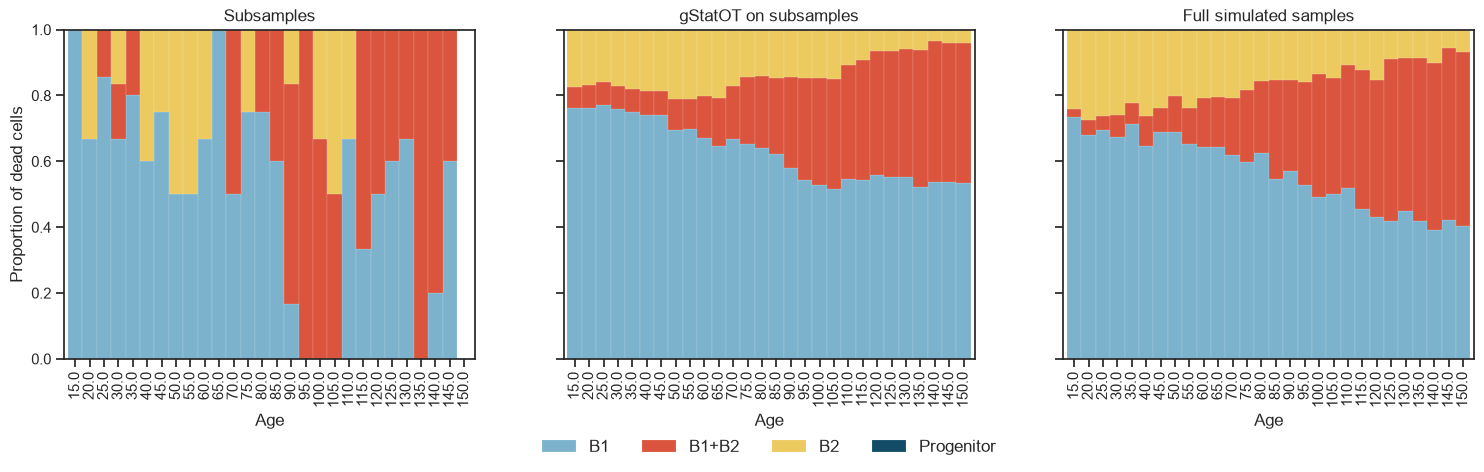

In [17]:
dead_prop_gsot = death_props(gSOT.adata, full_supp=True)
dead_prop_subsamples = death_props(gSOT.adata, full_supp=False)
dead_prop_full_sim = death_props(sim_adata, full_supp=False)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# set colors for cell_types 
width = 1.
linewidth = 0.1
ages = np.unique(gSOT.adata.obs['age'])
quarter_age = ages[len(ages)//4]
mid_age = ages[len(ages)//2]
three_quarter_age = ages[3*len(ages)//4]
ct = [quarter_age, mid_age, three_quarter_age] 
xlabel = r'Age ($t$)'

ct = ["B1", "B1+B2", 'B2', "Progenitor"]
cols = sns.color_palette("husl", n_colors=8)
ct_palette = {ct[0]: '#7cb2cc',
           ct[1]: '#db553e',
           ct[2]: '#ecca60',
           ct[3]: '#134c67'}


dead_prop_subsamples.plot(ax=ax1, title='Subsamples', xlabel='Age', ylabel='Proportion of dead cells', 
                    kind='bar', stacked=True, color=[ct_palette[ct] for ct in dead_prop_subsamples.columns],
                    width=width, linewidth=linewidth)

dead_prop_gsot.plot(ax=ax2, title='gStatOT on subsamples', xlabel='Age', ylabel='Proportion of dead cells', 
                    kind='bar', stacked=True, color=[ct_palette[ct] for ct in dead_prop_gsot.columns],
                    width=width, linewidth=linewidth)

dead_prop_full_sim.plot(ax=ax3, title='Full simulated samples', xlabel='Age', ylabel='Proportion of dead cells',
                    kind='bar', stacked=True, color=[ct_palette[ct] for ct in dead_prop_full_sim.columns],
                    width=width, linewidth=linewidth)
ax1.set_ylim(0, 1)
ax1.legend().remove()
ax3.legend().remove()
# place legend below plot of ax2
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=4, frameon=False, fontsize=12)
plt.tight_layout()



## StatOT

Cost scaled by  mean
Time 15.0, ran 5000 iterations, inf norm error: 2.1629e-05
Time 15.0, ran 10000 iterations, inf norm error: 2.1629e-05
Time 15.0, ran 15000 iterations, inf norm error: 2.1629e-05
Time 20.0, ran 5000 iterations, inf norm error: 3.5826e-05
Time 20.0, ran 10000 iterations, inf norm error: 3.5826e-05
Time 20.0, ran 15000 iterations, inf norm error: 3.5826e-05
Time 25.0, ran 5000 iterations, inf norm error: 1.0580e-06
Time 30.0, ran 5000 iterations, inf norm error: 3.9905e-05
Time 30.0, ran 10000 iterations, inf norm error: 3.9905e-05
Time 30.0, ran 15000 iterations, inf norm error: 3.9905e-05
Time 35.0, ran 5000 iterations, inf norm error: 1.7371e-05
Time 35.0, ran 10000 iterations, inf norm error: 1.7371e-05
Time 35.0, ran 15000 iterations, inf norm error: 1.7371e-05
Time 40.0, ran 5000 iterations, inf norm error: 1.8813e-05
Time 40.0, ran 10000 iterations, inf norm error: 1.8813e-05
Time 40.0, ran 15000 iterations, inf norm error: 1.8813e-05
Time 45.0, ran 5000 itera

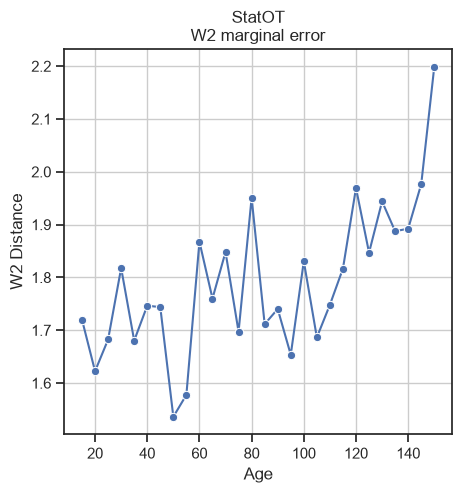

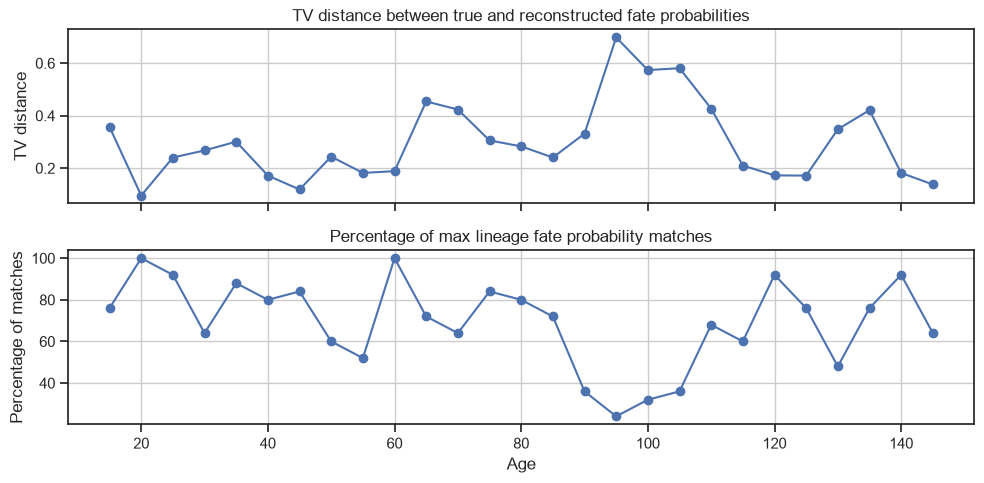

In [18]:
SOT = StatOT(adata=downsampled_adata.copy(), adata_keys=adata_keys, dt=dt, dtype=jnp.float32)

SOT_params = {'epsilon': 0.04,
              'lse': True,
              'cost_scaling': 'mean'}

SOT.fit(model_params=SOT_params, max_iter=15_000, verbose=True)

SOT.get_lin_fate_probs(label_key=adata_keys['cell_type_key'], all_labels=np.unique(sim_adata.obs[adata_keys['cell_type_key']]))
method_str = 'StatOT' 

sot_metric_tests = Metric_Evaluator(method=method_str,
                                        test_adata=SOT.adata,
                                        true_adata=sim_adata,
                                        time_key=adata_keys['time_key'],
                                        embed_key=adata_keys['embed_key'],
                                        exp_dir=None,
                                        full_supp=False)

sot_metric_tests.w2_marginal_error()
sot_metric_tests.fp_tv_error(label_key=adata_keys['cell_type_key'])

## Compare

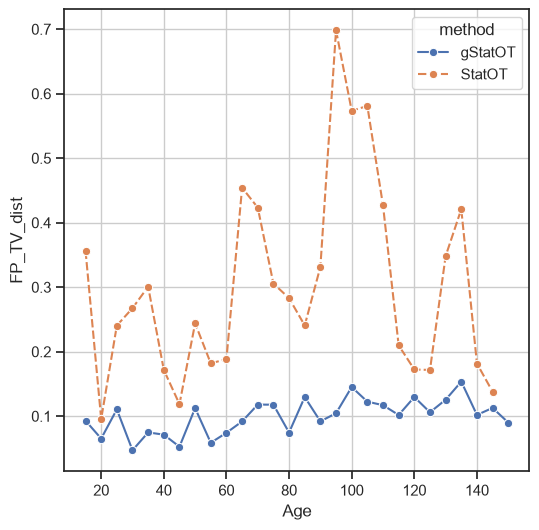

In [21]:
df_all = pd.concat([gsot_metric_tests.results_df, sot_metric_tests.results_df]).reset_index(drop=True)
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

sns.lineplot(data=df_all, x='Age', y='FP_TV_dist', hue='method', style='method', marker='o', ax=ax)
ax.grid()